# Reverse Diffusion: Training-Free Score Estimation

신경망 없이 score $s(x,t) = \nabla_x \log p_t(x)$를 추정하는 네 가지 방법을 구현하고, Euler-Maruyama와 Probability Flow ODE(RK4)로 reverse diffusion을 비교한다.

---

### Forward VP-SDE

$$dx = -\frac{1}{2}\beta(t)\,x\,dt + \sqrt{\beta(t)}\,dW$$

### Reverse SDE (Anderson, 1982)

$$dx = \left[-\frac{1}{2}\beta(t)\,x - \beta(t)\,s(x,t)\right]dt + \sqrt{\beta(t)}\,d\bar{W}$$

---

| Case | Score 추정 방법 |
|------|----------------|
| 0 | GMM 해석적 score (기준선) |
| 1 | Fokker-Planck PDE 수치적분 → $p_t$ |
| 2 | KDE(Parzen window) → 해석적 gradient |
| 3 | FFT spectral 미분 |
| 4 | Stein identity 커널 회귀 |

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.fft import fft2, ifft2, fftfreq

rng = np.random.default_rng(42)

---
## 공통: 데이터 & Forward SDE

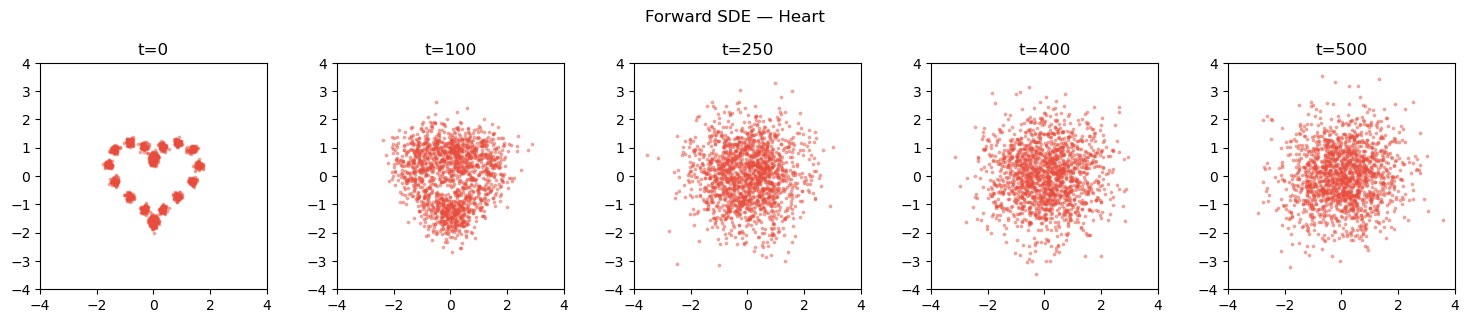

In [3]:
def make_samples(means, std, n_per_mode):
    return np.vstack([mu + rng.standard_normal((n_per_mode, 2)) * std for mu in means])

# Grid
g = np.linspace(-2, 2, 3)
grid_means = np.array([[x, y] for y in g for x in g])

# Moons
th = np.linspace(0, np.pi, 300)
moon_means = np.vstack([
    np.c_[np.cos(th), np.sin(th)],
    np.c_[1 - np.cos(th), 1 - np.sin(th) - 0.5]
])

# Heart
t = np.linspace(0, 2*np.pi, 20, endpoint=False)
heart_means = np.c_[16*np.sin(t)**3,
                    13*np.cos(t)-5*np.cos(2*t)-2*np.cos(3*t)-np.cos(4*t)] / 10

datasets = {
    "grid":  make_samples(grid_means,  std=0.12, n_per_mode=150),
    "moons": make_samples(moon_means,  std=0.06, n_per_mode=1),
    "heart": make_samples(heart_means, std=0.07, n_per_mode=80),
}

# ── Noise schedule ────────────────────────────────────────────────────────────
T     = 500
betas = np.linspace(1e-4, 0.02, T)
alpha_bar = np.cumprod(1 - betas)
sigma2_t  = 1 - alpha_bar

# ── Forward SDE ───────────────────────────────────────────────────────────────
SAVE_EVERY = 10

def forward_sde(x0):
    saved = {0: x0.copy()}
    x = x0.copy()
    for i, beta in enumerate(betas):
        x = x * (1 - 0.5*beta) + np.sqrt(beta) * rng.standard_normal(x.shape)
        t = i + 1
        if t % SAVE_EVERY == 0 or t == T:
            saved[t] = x.copy()
    return saved

fwd = {name: forward_sde(x0) for name, x0 in datasets.items()}

def get_refs(fwd_traj, t_idx):
    t_real = t_idx + 1
    ts = np.array(sorted(fwd_traj.keys()))
    return fwd_traj[ts[np.argmin(np.abs(ts - t_real))]]

# ── Heart forward 확인 ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, t in zip(axes, [0, 100, 250, 400, 500]):
    refs = get_refs(fwd["heart"], t-1) if t > 0 else fwd["heart"][0]
    ax.scatter(*refs.T, s=3, alpha=0.4, c="#e74c3c")
    ax.set_title(f"t={t}"); ax.set_xlim(-4,4); ax.set_ylim(-4,4); ax.set_aspect("equal")
fig.suptitle("Forward SDE — Heart", y=1.01); plt.tight_layout(); plt.show()

- Forward VP-SDE
    $$
    dx = -\frac{1}{2}\beta(t)\,x\,dt + \sqrt{\beta(t)}dW
    $$

    $$
    x_t-x_{t-1}=-\frac{1}{2}\beta_t x_{t-1}+\sqrt{\beta_t}\epsilon
    $$

    $$
    x_t=\left(1-\frac{1}{2}\beta_t \right) x_{t-1}+\sqrt{\beta_t}\epsilon
    $$
    <br>
    
    $1-\frac{1}{2}\beta_t \equiv \sqrt{1-\beta_t}$ ($\beta_t$가 작을 때) 이므로:  
    $$
    x_t=\sqrt{1-\beta_t}x_{t-1}+\sqrt{\beta_t}\epsilon
    = \sqrt{\alpha_t}x_{t-1}+\sqrt{1-\alpha_t}\epsilon
    $$
    $$\alpha_t = 1 - \beta_t$$



### 한 스텝 점화식
 
$$\mathbf{x}_t = \sqrt{\alpha_t}\,\mathbf{x}_{t-1} + \sqrt{1-\alpha_t}\,\boldsymbol{\epsilon}_t, \qquad \boldsymbol{\epsilon}_t \sim \mathcal{N}(0,I)$$
 
### 반복 대입
 
**$t=1$:**
 
$$\mathbf{x}_1 = \sqrt{\alpha_1}\,\mathbf{x}_0 + \sqrt{1-\alpha_1}\,\boldsymbol{\epsilon}_1$$
 
**$t=2$:** $\mathbf{x}_1$을 대입:
 
$$\mathbf{x}_2 = \sqrt{\alpha_2}\,\mathbf{x}_1 + \sqrt{1-\alpha_2}\,\boldsymbol{\epsilon}_2$$
 
$$= \sqrt{\alpha_2}\left(\sqrt{\alpha_1}\,\mathbf{x}_0 + \sqrt{1-\alpha_1}\,\boldsymbol{\epsilon}_1\right) + \sqrt{1-\alpha_2}\,\boldsymbol{\epsilon}_2$$
 
$$= \sqrt{\alpha_1\alpha_2}\,\mathbf{x}_0 + \underbrace{\sqrt{\alpha_2(1-\alpha_1)}\,\boldsymbol{\epsilon}_1 + \sqrt{1-\alpha_2}\,\boldsymbol{\epsilon}_2}_{\text{두 독립 가우시안의 합}}$$
 
### 노이즈 항 합치기
 
두 독립 가우시안의 합의 분산:
 
$$\text{Var} = \alpha_2(1-\alpha_1) + (1-\alpha_2) = \alpha_2 - \alpha_1\alpha_2 + 1 - \alpha_2 = 1 - \alpha_1\alpha_2$$
 
따라서 두 노이즈를 하나의 가우시안으로 합칠 수 있다:
 
$$\sqrt{\alpha_2(1-\alpha_1)}\,\boldsymbol{\epsilon}_1 + \sqrt{1-\alpha_2}\,\boldsymbol{\epsilon}_2 = \sqrt{1-\alpha_1\alpha_2}\,\boldsymbol{\epsilon}, \qquad \boldsymbol{\epsilon}\sim\mathcal{N}(0,I)$$
 
따라서:
 
$$\mathbf{x}_2 = \sqrt{\alpha_1\alpha_2}\,\mathbf{x}_0 + \sqrt{1-\alpha_1\alpha_2}\,\boldsymbol{\epsilon}$$

### 일반화
 
같은 과정을 $t$번 반복하면 노이즈 항의 분산이:
 
$$1-\alpha_1\alpha_2, \quad 1-\alpha_1\alpha_2\alpha_3, \quad \ldots, \quad 1-\prod_{s=1}^t\alpha_s = 1-\bar{\alpha}_t$$
 
따라서:
 
$$\boxed{\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}, \qquad \bar{\alpha}_t = \prod_{s=1}^t\alpha_s}$$

---
## 공통: Reverse Integrators

## Reverse SDE

$$dx = \left[-\frac{1}{2}\beta(t)\,x - \beta(t)\,s(x,t)\right]dt + \sqrt{\beta(t)}\,d\bar{W}$$

## Euler-Maruyama (SDE Solver)
$$x_{t-1} = x_t + \beta_t\!\left(-\tfrac{1}{2}x_t - s(x_t,t)\right)\Delta t + \sqrt{\beta_t\Delta t}\,\epsilon$$

## Probability Flow ODE (RK4: ODE Solver)
### 핵심 목표
 
**노이즈를 없애되, $p_t$의 시간 변화는 동일하게 유지**
 
SDE와 ODE는 서로 다른 방정식이지만, **Fokker-Planck 수준에서 일치하면 같은 $p_t$를 만들어냄.**
 
---
 
### Step 1: Reverse SDE의 Fokker-Planck 방정식
 
Reverse SDE:
 
$$dx = \underbrace{\left[-\frac{1}{2}\beta x - \beta s\right]}_{f}\,dt + \underbrace{\sqrt{\beta}}_{g}\,d\bar{W}$$
 
이 SDE의 Fokker-Planck 방정식:
 
$$\frac{\partial p}{\partial t} = \underbrace{-\nabla\cdot(f\cdot p)}_{\text{drift 기여}} + \underbrace{\frac{1}{2}g^2\,\nabla^2 p}_{\text{노이즈 기여}}$$
 
---
 
### Step 2: ODE의 Fokker-Planck 방정식
 
ODE $\dfrac{dx}{dt} = \tilde{f}$의 Fokker-Planck:
 
$$\frac{\partial p}{\partial t} = -\nabla\cdot(\tilde{f}\cdot p)$$
 
노이즈가 없으니 두 번째 항이 없음.
 
---
 
### Step 3: 두 Fokker-Planck를 같게 놓기
 
$$-\nabla\cdot(\tilde{f}\cdot p) = -\nabla\cdot(f\cdot p) + \frac{1}{2}g^2\,\nabla^2 p$$
 
우변의 노이즈 항 $\dfrac{1}{2}g^2\,\nabla^2 p$을 $-\nabla\cdot(\cdot\, p)$ 꼴로 변환.
 
$$\frac{1}{2}g^2\,\nabla^2 p = \frac{1}{2}g^2\,\nabla\cdot(\nabla p)$$
 
여기서 $\nabla p = p \cdot \nabla\log p = p \cdot s$ 이므로:
 
$$= \nabla\cdot\!\left(\frac{1}{2}g^2\, s\cdot p\right)$$
 
따라서:
 
$$-\nabla\cdot(\tilde{f}\cdot p) = -\nabla\cdot(f\cdot p) + \nabla\cdot\!\left(\frac{1}{2}g^2\,s\cdot p\right) = -\nabla\cdot\!\left[\left(f - \frac{1}{2}g^2\,s\right)p\right]$$
 
$$\boxed{\tilde{f} = f - \frac{1}{2}g^2\,s}$$
 
---
 
### Step 4: 대입
 
$f = -\dfrac{1}{2}\beta x - \beta s$, $\quad g^2 = \beta$ 를 대입:
 
$$\tilde{f} = \left(-\frac{1}{2}\beta x - \beta s\right) - \frac{1}{2}\beta s = -\frac{1}{2}\beta x - \frac{1}{2}\beta s$$
 
최종 Probability Flow ODE:
 
$$\frac{dx}{dt} = -\frac{1}{2}\beta(t)\,x - \frac{1}{2}\beta(t)\,s(x,t)$$
 
---

In [59]:
SCORE_CLIP = 15.0

def clip_score(s):
    norm = np.linalg.norm(s, axis=1, keepdims=True).clip(1e-8)
    return s * np.minimum(1.0, SCORE_CLIP / norm)

def reverse_euler(x_T, score_fn, save_steps=(500,400,250,100,0)):
    """Euler-Maruyama (stochastic SDE)"""
    traj = {T: x_T.copy()}
    x = x_T.copy()
    for t_idx in reversed(range(T)):
        b = betas[t_idx]
        s = clip_score(score_fn(x, t_idx))
        x = x + b*(-0.5*x - s) + np.sqrt(b)*rng.standard_normal(x.shape)
        if t_idx in save_steps:
            traj[t_idx] = x.copy()
    traj[0] = x.copy()
    return traj

def reverse_rk4(x_T, score_fn, save_steps=(500,400,250,100,0)):
    """
    Probability Flow ODE (deterministic), RK4 적분
    dx/dt = -β(t)/2 · x  -  β(t)/2 · s(x,t)
    """
    traj = {T: x_T.copy()}
    x = x_T.copy()
    dt = -1.0   # 역방향이므로 음수

    def f(x, t_idx):
        b = betas[max(t_idx, 0)]
        s = clip_score(score_fn(x, max(t_idx, 0)))
        return -0.5*b*x - 0.5*b*s

    for t_idx in reversed(range(T)):
        k1 = f(x,          t_idx)
        k2 = f(x + 0.5*dt*k1, t_idx)
        k3 = f(x + 0.5*dt*k2, t_idx)
        k4 = f(x +     dt*k3, t_idx - 1)
        x  = x + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
        if t_idx in save_steps:
            traj[t_idx] = x.copy()
    traj[0] = x.copy()
    return traj

def plot_compare(traj_euler, traj_rk4, title,
                 steps=(500,400,250,100,0),
                 c_euler="#3498db", c_rk4="#e74c3c"):
    fig, axes = plt.subplots(2, len(steps), figsize=(3*len(steps), 6))
    for col, t in enumerate(steps):
        for row, (traj, c, label) in enumerate([
            (traj_euler, c_euler, "Euler-Maruyama"),
            (traj_rk4,  c_rk4,  "RK4 (Prob. Flow ODE)"),
        ]):
            ax = axes[row, col]
            pts = traj.get(t, None)
            if pts is not None:
                ax.scatter(*pts.T, s=4, alpha=0.35, c=c)
            ax.set_xlim(-4,4); ax.set_ylim(-4,4); ax.set_aspect("equal")
            if col == 0: ax.set_ylabel(label, fontsize=9)
            if row == 0: ax.set_title(f"t={t}")
    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

---
## Case 0 — GMM Exact Score + Euler vs RK4

VP-SDE의 marginal은 GMM을 유지:
$$p_t(x) = \frac{1}{K}\sum_k \mathcal{N}\!\left(x;\;\sqrt{\bar\alpha_t}\mu_k,\;\bar\alpha_t\sigma_k^2 + \sigma_t^2\right)$$

Score는 각 모드 score의 **사후확률 가중 합**:
$$s(x,t) = \sum_k w_k(x,t)\cdot\left(-\frac{x-\sqrt{\bar\alpha_t}\mu_k}{\bar\alpha_t\sigma_k^2+\sigma_t^2}\right), \qquad w_k = \frac{p_t^{(k)}(x)}{\sum_j p_t^{(j)}(x)}$$

이것이 신경망 없이 구할 수 있는 **이론상 완벽한 score**. Euler와 RK4를 비교하면 integrator 차이만 분리해서 볼 수 있다.

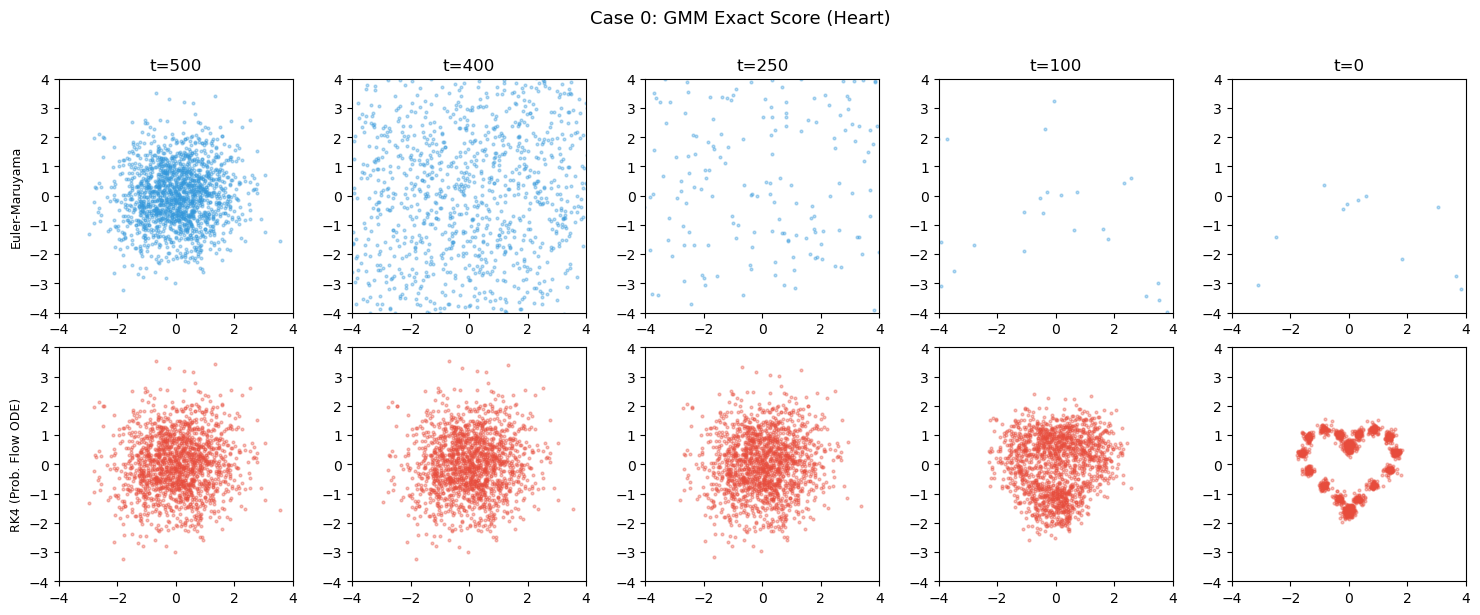

In [60]:
# Heart: GMM 모드들 (make_heart와 동일한 중심점)
_t = np.linspace(0, 2*np.pi, 20, endpoint=False)
H_MEANS = np.c_[16*np.sin(_t)**3,
                13*np.cos(_t)-5*np.cos(2*_t)-2*np.cos(3*_t)-np.cos(4*_t)] / 10  # (20,2)
H_VAR   = 0.07**2

def gmm_score(x, t_idx):
    ab    = alpha_bar[t_idx]
    s2    = sigma2_t[t_idx]
    mu_t  = np.sqrt(ab) * H_MEANS       # (K,2)
    var_t = ab * H_VAR + s2             # scalar

    diff   = x[:,None,:] - mu_t[None,:,:]   # (N,K,2)
    log_pk = -(diff**2).sum(-1) / (2*var_t)
    log_pk -= log_pk.max(1, keepdims=True)
    wk = np.exp(log_pk)
    wk /= wk.sum(1, keepdims=True)

    score_k = -diff / var_t             # (N,K,2)
    return (wk[:,:,None] * score_k).sum(1)  # (N,2)

x_T = fwd["heart"][T].copy()
traj_e0 = reverse_euler(x_T, gmm_score)
traj_r0 = reverse_rk4  (x_T, gmm_score)

plot_compare(traj_e0, traj_r0, "Case 0: GMM Exact Score (Heart)")

---
## Case 1 — Fokker-Planck PDE → $p_t$ → Score

VP-SDE에 대응하는 **Fokker-Planck 방정식**:
$$\frac{\partial p_t}{\partial t} = \frac{\beta(t)}{2}\left[\nabla\cdot(x\,p_t) + \Delta p_t\right]$$

2D 격자 위에서 중심차분으로 직접 수치적분 → 각 $t$의 $p_t$ 격자 획득.  
Score는 log 공간 중심차분:
$$s(x,t) \approx \frac{\log p_t(x+he_i) - \log p_t(x-he_i)}{2h}$$

> 샘플 기반 근사 없이 **$p_t$ 자체를 직접 진화**시키는 유일한 방법.

Fokker-Planck forward integration (Heart)...
Done.


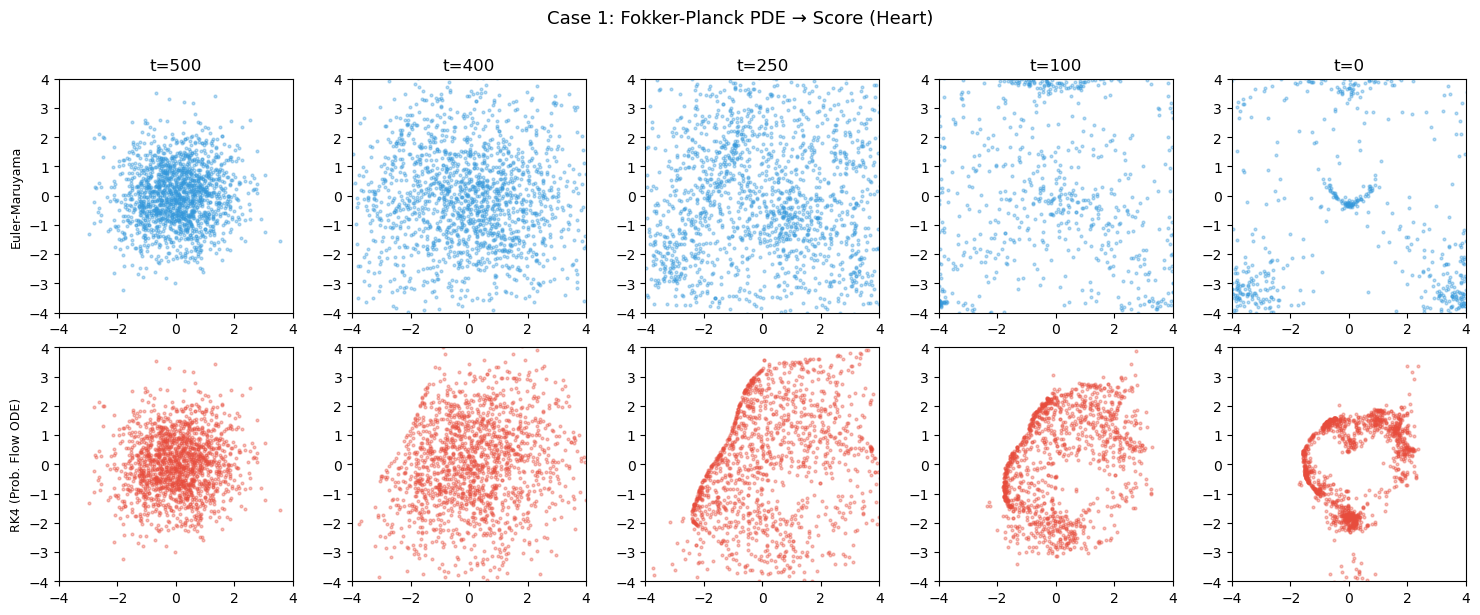

In [61]:
GN   = 80
GLIM = 4.0
gdx  = 2*GLIM / (GN-1)
gxs  = np.linspace(-GLIM, GLIM, GN)
XG, YG = np.meshgrid(gxs, gxs, indexing="ij")

def samples_to_p(samples, sigma=1.0):
    h, _, _ = np.histogram2d(samples[:,0], samples[:,1],
                              bins=GN, range=[[-GLIM,GLIM]]*2)
    p = gaussian_filter(h.astype(float), sigma=sigma) + 1e-30
    return p / (p.sum() * gdx**2)

def fp_step(p, beta):
    r = np.roll; d = gdx
    dpx = (r(p,-1,0) - r(p,1,0)) / (2*d)
    dpy = (r(p,-1,1) - r(p,1,1)) / (2*d)
    d2x = (r(p,-1,0) - 2*p + r(p,1,0)) / d**2
    d2y = (r(p,-1,1) - 2*p + r(p,1,1)) / d**2
    dpdt = 0.5*beta*((p + XG*dpx) + (p + YG*dpy) + d2x + d2y)
    p_new = np.clip(p + dpdt, 1e-30, None)
    return p_new / (p_new.sum() * gdx**2)

def p_to_score_grid(p):
    lp = np.log(p + 1e-300)
    r = np.roll; d = gdx
    return np.stack([(r(lp,-1,0)-r(lp,1,0))/(2*d),
                     (r(lp,-1,1)-r(lp,1,1))/(2*d)], -1)

def grid_interp(sg, x):
    ix = np.clip(((x[:,0]+GLIM)/gdx).astype(int), 0, GN-1)
    iy = np.clip(((x[:,1]+GLIM)/gdx).astype(int), 0, GN-1)
    return sg[ix, iy, :]

# ── FP 순방향 적분 (Heart 데이터 기반) ───────────────────────────────────────
print("Fokker-Planck forward integration (Heart)...")
p_fp = [None] * (T+1)
p_fp[0] = samples_to_p(datasets["heart"], sigma=1.2)
for t in range(T):
    p_fp[t+1] = fp_step(p_fp[t], betas[t])
print("Done.")

def fp_score(x, t_idx):
    return grid_interp(p_to_score_grid(p_fp[t_idx+1]), x)

x_T = fwd["heart"][T].copy()
traj_e1 = reverse_euler(x_T, fp_score)
traj_r1 = reverse_rk4  (x_T, fp_score)

plot_compare(traj_e1, traj_r1, "Case 1: Fokker-Planck PDE → Score (Heart)")

---
## Case 2 — KDE (Interpolation) → 수치 미분 Score

Forward 샘플 $\{x_i^{(t)}\}$로 Parzen window KDE:
$$\hat{p}_t(x) = \frac{1}{N}\sum_i K_h(x - x_i^{(t)}), \quad K_h(u) = e^{-\|u\|^2/2h^2}$$

Gradient를 **해석적으로** 계산 (수치 차분 없이):
$$\nabla_x\log\hat{p}_t(x) = \frac{\sum_i \left(-\frac{x-x_i}{h^2}\right)K_h(x-x_i)}{\sum_i K_h(x-x_i)}$$

> 저밀도 영역에서 분모 $\to 0$ → score 폭발이 취약점.  
> bandwidth $h$를 크게 잡아 과평활화하면 안정되지만 세부구조를 잃는다.

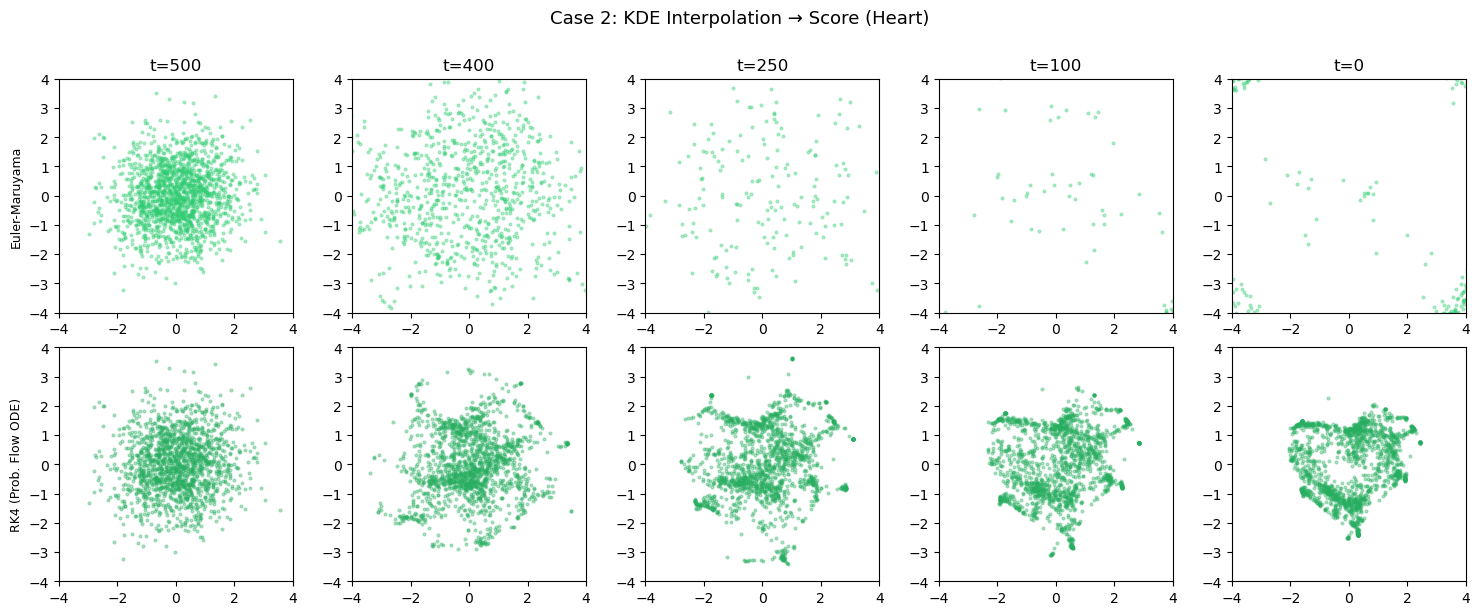

In [62]:
def parzen_score(x, refs, bw=None):
    N, D = refs.shape
    if bw is None:
        bw = N**(-1/(D+4)) * refs.std()
    h2   = bw**2
    diff  = x[:,None,:] - refs[None,:,:]
    K     = np.exp(-(diff**2).sum(-1) / (2*h2))
    p_hat = K.sum(1, keepdims=True) + 1e-30
    grad  = -(diff/h2 * K[:,:,None]).sum(1)
    return grad / p_hat

fwd_heart_c2 = fwd["heart"]
saved_ts_c2  = np.array(sorted(fwd_heart_c2.keys()))

def kde_score(x, t_idx):
    nearest = saved_ts_c2[np.argmin(np.abs(saved_ts_c2 - (t_idx+1)))]
    return parzen_score(x, fwd_heart_c2[nearest])

x_T = fwd["heart"][T].copy()
traj_e2 = reverse_euler(x_T, kde_score)
traj_r2 = reverse_rk4  (x_T, kde_score)

plot_compare(traj_e2, traj_r2, "Case 2: KDE Interpolation → Score (Heart)",
             c_euler="#2ecc71", c_rk4="#27ae60")

---
## Case 3 — FFT Spectral 미분 → Score

격자 위의 $\log\hat{p}_t$를 Fourier 공간에서 미분:
$$\mathcal{F}\{\partial_{x_i} f\}(\mathbf{k}) = ik_i\cdot\mathcal{F}\{f\}(\mathbf{k})$$

$$\nabla_x\log\hat{p}_t = \mathcal{F}^{-1}\{i\mathbf{k}\cdot\mathcal{F}\{\log\hat{p}_t\}\}$$

격자 해상도 $G$ 내에서 **spectral 정밀도** (중심차분보다 이론적으로 정확).  
단, 주기 경계 조건 가정 → Hann window로 경계 감쇠 필요.

FFT score cache 구축 (Heart)...
Done.


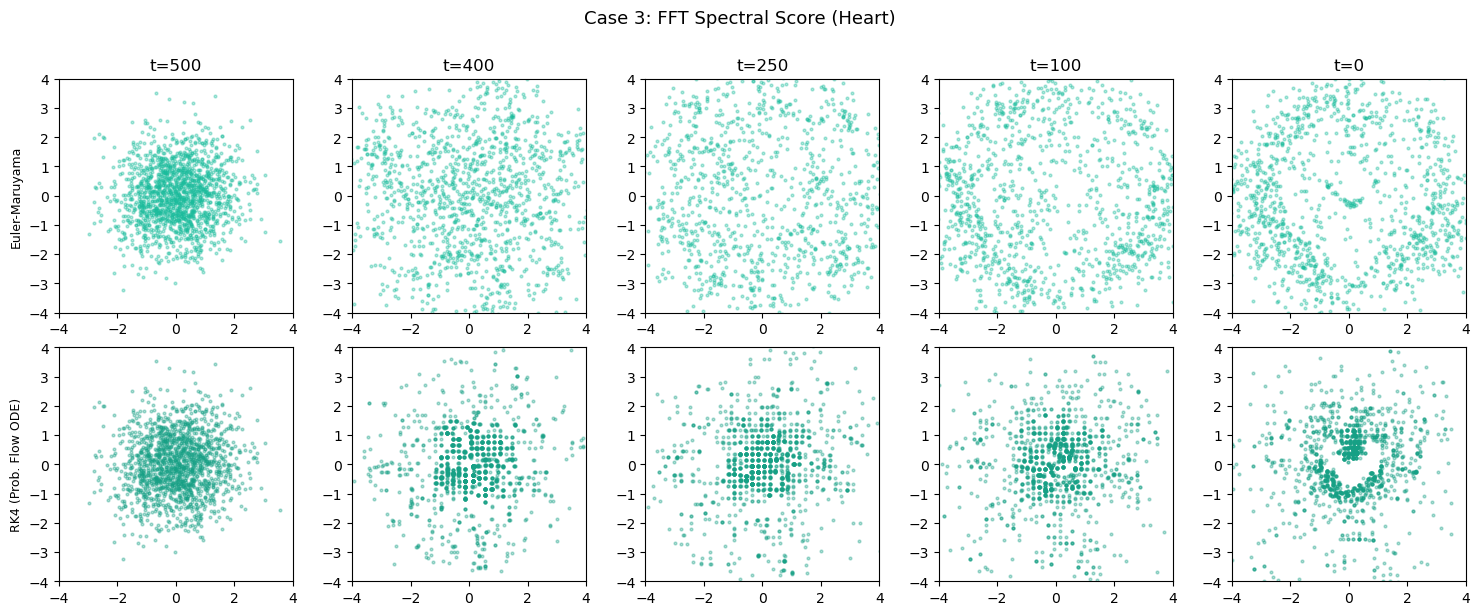

In [63]:
hann2d = np.outer(np.hanning(GN), np.hanning(GN))
freq   = fftfreq(GN, d=gdx) * 2*np.pi
Kx, Ky = np.meshgrid(freq, freq, indexing="ij")

def fft_score_grid(samples):
    p    = samples_to_p(samples, sigma=1.2)
    p_w  = p * hann2d + 1e-30
    p_w /= p_w.sum() * gdx**2
    F    = fft2(np.log(p_w))
    gx   = np.real(ifft2(1j*Kx*F))
    gy   = np.real(ifft2(1j*Ky*F))
    return np.stack([gx, gy], -1)

print("FFT score cache 구축 (Heart)...")
fft_cache = {t: fft_score_grid(samp) for t, samp in fwd["heart"].items()}
fft_ts    = np.array(sorted(fft_cache.keys()))
print("Done.")

def fft_score(x, t_idx):
    nearest = fft_ts[np.argmin(np.abs(fft_ts - (t_idx+1)))]
    return grid_interp(fft_cache[nearest], x)

x_T = fwd["heart"][T].copy()
traj_e3 = reverse_euler(x_T, fft_score)
traj_r3 = reverse_rk4  (x_T, fft_score)

plot_compare(traj_e3, traj_r3, "Case 3: FFT Spectral Score (Heart)",
             c_euler="#1abc9c", c_rk4="#16a085")

---
## Case 4 — Langevin MC + Stein Identity → Score

$p_t$를 명시적으로 추정하지 않고, **Stein identity**로 score를 샘플에서 직접 회귀:

$$\mathbb{E}_{p_t}\!\left[s(x)\phi(x) + \nabla_x\phi(x)\right] = 0 \quad \forall\phi$$

커널 $K(x,x')$를 $\phi$로 쓰면 선형시스템:
$$(K_{NN} + \lambda I)\,\mathbf{c} = \sum_j \nabla_{x_j}K(x_i,x_j)$$
$$\hat{s}(x) = K(x, X)\,\mathbf{c}$$

> $p_t$를 추정하지 않으므로 **저밀도 분모 문제가 없음** — 다른 방법들의 핵심 취약점을 피한다.

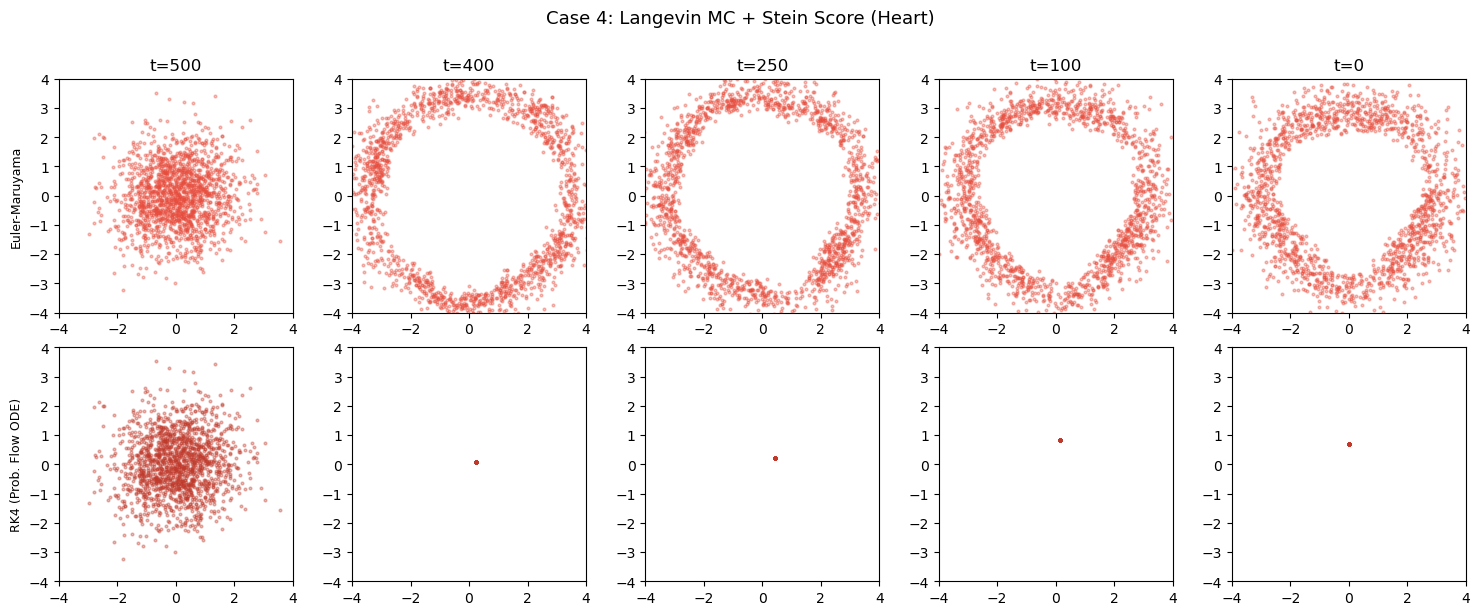

In [64]:
def stein_score(x, refs, lam=1e-3):
    """
    x    : (Q,2) query
    refs : (N,2) forward 샘플 (p_t proxy)
    """
    N, D = refs.shape
    bw   = refs.std() * N**(-1/(D+4))
    h2   = bw**2

    diff_nn  = refs[:,None,:] - refs[None,:,:]   # (N,N,2)
    K_nn     = np.exp(-(diff_nn**2).sum(-1) / (2*h2))  # (N,N)
    rhs      = (-(diff_nn/h2) * K_nn[:,:,None]).sum(1)  # (N,2)
    c        = np.linalg.solve(K_nn + lam*np.eye(N), rhs)  # (N,2)

    diff_qn  = x[:,None,:] - refs[None,:,:]     # (Q,N,2)
    K_qn     = np.exp(-(diff_qn**2).sum(-1) / (2*h2))  # (Q,N)
    return K_qn @ c   # (Q,2)

fwd_heart  = fwd["heart"]
heart_ts   = np.array(sorted(fwd_heart.keys()))

def stein_score_fn(x, t_idx):
    nearest = heart_ts[np.argmin(np.abs(heart_ts - (t_idx+1)))]
    return stein_score(x, fwd_heart[nearest])

x_T = fwd["heart"][T].copy()
traj_e4 = reverse_euler(x_T, stein_score_fn)
traj_r4 = reverse_rk4  (x_T, stein_score_fn)

plot_compare(traj_e4, traj_r4, "Case 4: Langevin MC + Stein Score (Heart)",
             c_euler="#e74c3c", c_rk4="#c0392b")

---
## 최종 비교: t=0 복원 결과

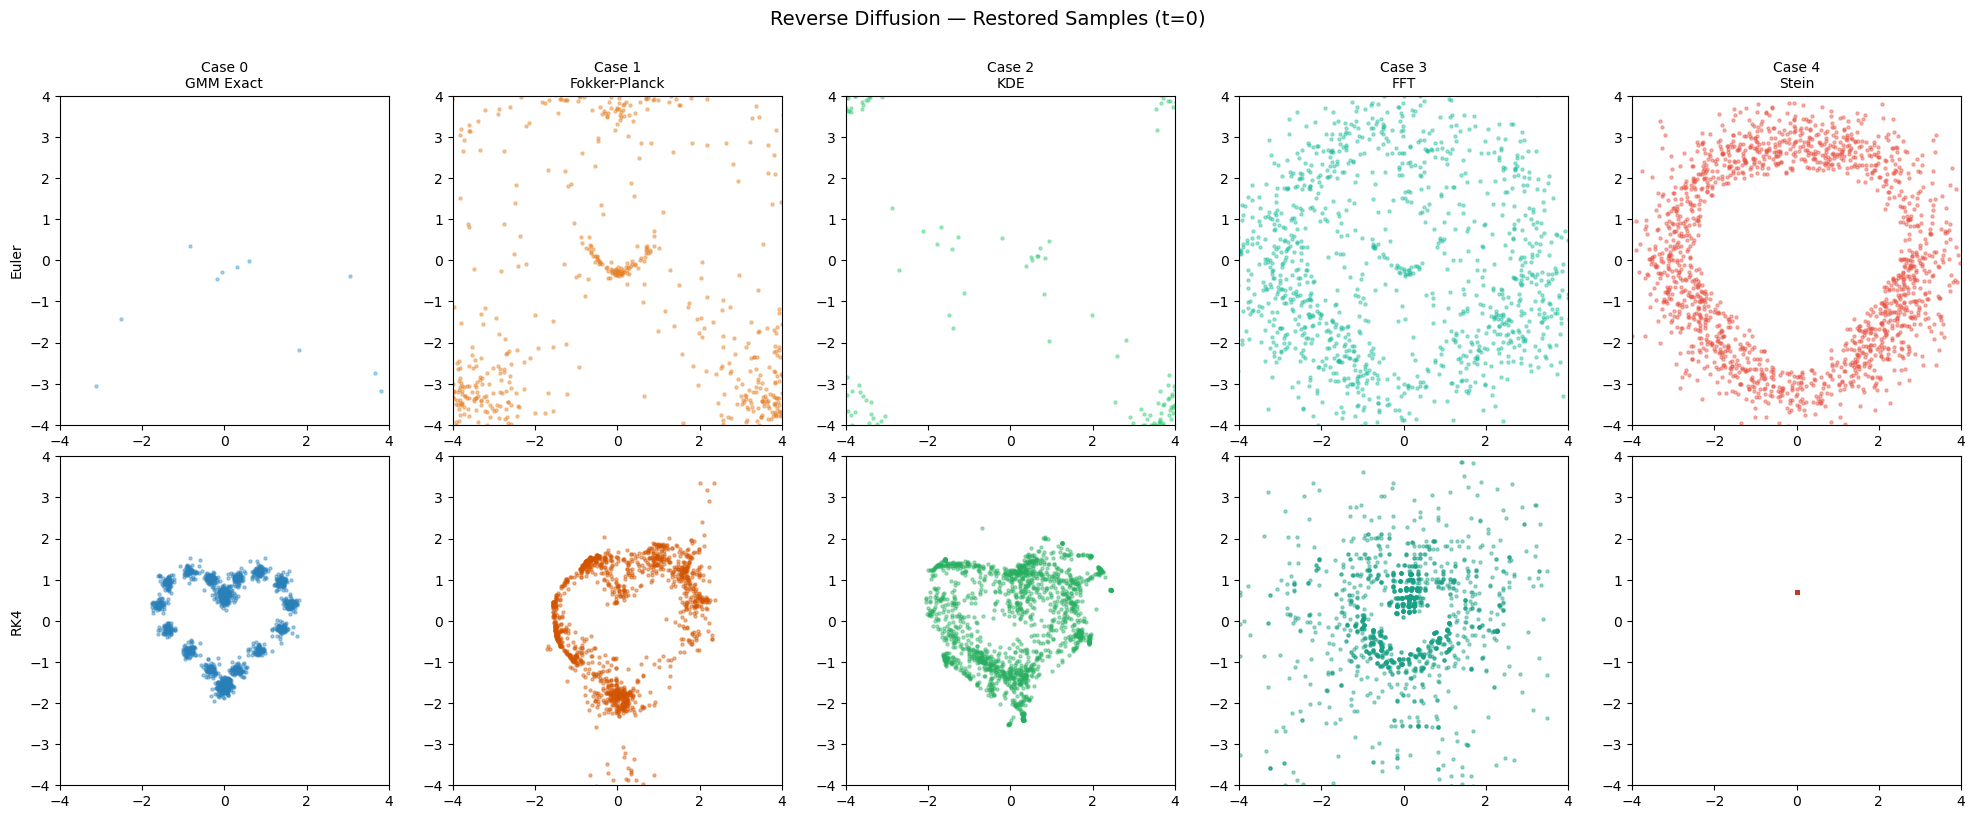

In [ ]:
cases = [
    ("Case 0\nGMM Exact",    traj_e0, traj_r0, "#3498db", "#2980b9"),
    ("Case 1\nFokker-Planck",traj_e1, traj_r1, "#e67e22", "#d35400"),
    ("Case 2\nKDE",           traj_e2, traj_r2, "#2ecc71", "#27ae60"),
    ("Case 3\nFFT",           traj_e3, traj_r3, "#1abc9c", "#16a085"),
    ("Case 4\nStein",         traj_e4, traj_r4, "#e74c3c", "#c0392b"),
]

fig, axes = plt.subplots(2, len(cases), figsize=(4*len(cases), 8))
for col, (title, te, tr, ce, cr) in enumerate(cases):
    for row, (traj, c, method) in enumerate([
        (te, ce, "Euler"), (tr, cr, "RK4")
    ]):
        ax = axes[row, col]
        ax.scatter(*traj[0].T, s=5, alpha=0.4, c=c)
        ax.set_xlim(-4,4); ax.set_ylim(-4,4); ax.set_aspect("equal")
        if row == 0: ax.set_title(title, fontsize=10)
        if col == 0: ax.set_ylabel(method, fontsize=10)

fig.suptitle("Reverse Diffusion — Restored Samples (t=0)", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()